In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Class Labels Mapping (اسم الفولدر ورقمه):
Class 0: Normal
Class 1: Pneumonia-Bacterial
Class 2: Viral Pneumonia

Train distribution:
Normal: 2289 images
Pneumonia-Bacterial: 2100 images
Viral Pneumonia: 2055 images

Validation distribution:
Normal: 490 images
Pneumonia-Bacterial: 450 images
Viral Pneumonia: 440 images
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 967s 2s/step - accuracy: 0.5864 - loss: 0.4235 - val_accuracy: 0.7964 - val_loss: 0.3530
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 366s 907ms/step - accuracy: 0.7792 - loss: 0.3498 - val_accuracy: 0.8268 - val_loss: 0.3226
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 366s 907ms/step - accuracy: 0.8092 - loss: 0.3178 - val_accuracy: 0.8362 - val_loss: 0.2955
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 366s 907ms/step - accuracy: 0.8166 - loss: 0.2946 - val_accuracy

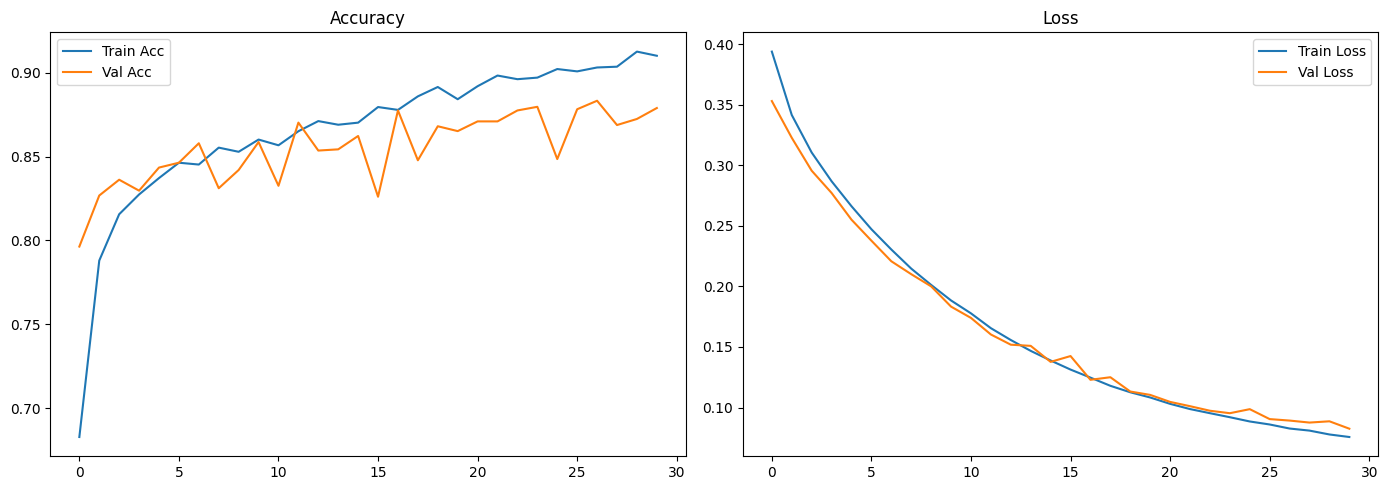

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import cv2
import numpy as np

# ربط الدرايف
drive.mount('/content/drive')

# إعداد المسارات
train_path = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
val_path = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (600, 600)
BATCH_SIZE = 16

#  قراءة الفئات (من الترين)
classes = sorted(os.listdir(train_path))
print("\n Class Labels Mapping (اسم الفولدر ورقمه):")
for idx, cls_name in enumerate(classes):
    print(f"Class {idx}: {cls_name}")

#  جمع المسارات والتسميات - Train
train_file_paths, train_labels = [], []
for idx, cls in enumerate(classes):
    cls_folder = os.path.join(train_path, cls)
    for fname in os.listdir(cls_folder):
        train_file_paths.append(os.path.join(cls_folder, fname))
        train_labels.append(idx)

print(f"\nTrain distribution:")
for idx, cls in enumerate(classes):
    count = sum(1 for l in train_labels if l == idx)
    print(f"{cls}: {count} images")

# جمع المسارات والتسميات - Validation (بدون أي تلاعب)
val_file_paths, val_labels = [], []
for idx, cls in enumerate(classes):
    cls_folder = os.path.join(val_path, cls)
    for fname in os.listdir(cls_folder):
        val_file_paths.append(os.path.join(cls_folder, fname))
        val_labels.append(idx)

print(f"\nValidation distribution:")
for idx, cls in enumerate(classes):
    count = sum(1 for l in val_labels if l == idx)
    print(f"{cls}: {count} images")

#  دالة التحميل والمعالجة
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(
        load_and_preprocess,
        [path, label],
        [tf.float32, tf.int32]
    )
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

#  Pipeline - Train (مع أوغمنتيشن)
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_file_paths, train_labels))
    .shuffle(len(train_file_paths))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Pipeline - Validation (بدون Aug)
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_file_paths, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


import tensorflow.keras.backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd

# دالة فوكال لوس
def focal_loss(gamma=2., alpha=0.25):
    def loss_fn(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.-eps)
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1-y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss_fn

# بناء النموذج
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-60]:
    layer.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = Dropout(0.5)(x)
outputs = Dense(len(classes), activation='softmax')(x)
x= convulation(128 , activation = 'relu ')
model = Model(base_model.input, outputs)

# تجميع
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# تدريب
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# حفظ النتائج
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/vgg16_stream_no_oversample.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/vgg16_stream_without_oversample_results.csv",
    index=False
)

# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
from google.colab import drive
# ربط الدرايف
drive.mount('/content/drive')


Mounted at /content/drive


Classification Report:
                      precision    recall  f1-score   support

             Normal       0.98      0.96      0.97       492
Pneumonia-Bacterial       0.81      0.84      0.82       451
    Viral Pneumonia       0.81      0.79      0.80       442

           accuracy                           0.87      1385
          macro avg       0.87      0.86      0.86      1385
       weighted avg       0.87      0.87      0.87      1385



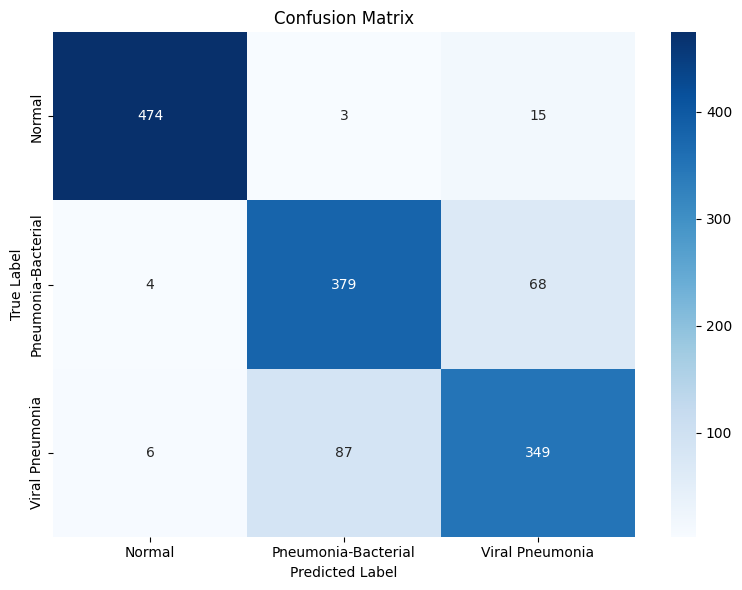

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# المسارات
MODEL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/vgg16_stream_no_oversample.keras"
TEST_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Test"
IMG_SIZE = (600, 600)
BATCH_SIZE = 16

# أسماء الفئات حسب الترتيب
class_names = sorted(os.listdir(TEST_PATH))

# تحميل النموذج
model = tf.keras.models.load_model(MODEL_PATH)

# دالة CLAHE للمعالجة
def load_and_preprocess_image(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

def tf_wrapper(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess_image, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    return img, lbl

# تحميل بيانات الاختبار
test_file_paths = []
test_labels = []

for idx, cls in enumerate(class_names):
    cls_folder = os.path.join(TEST_PATH, cls)
    for fname in os.listdir(cls_folder):
        test_file_paths.append(os.path.join(cls_folder, fname))
        test_labels.append(idx)

# Dataset
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_file_paths, test_labels))
    .map(tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# التنبؤ
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report:\n", report)

# رسم Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
